# Разработка алгоритма жадного добавления

Для сравнительной оценки получаемых результатов с подходом описанным в СП 11.13130.2009

In [2]:
import osmnx as ox
import geopandas as gpd
import pandas as pd
import numpy as np
import networkx as nx

# Загрузка исходных данных

Здесь используем данные для Сосновоборска, как тестовые.

5514 12199


c:\Users\obsid\.conda\envs\ox2\Lib\site-packages\pyogrio\geopandas.py:265: UserWarning: More than one layer found in 'buildings.gpkg': 'buildings' (default), 'здания'. Specify layer parameter to avoid this warning.
  result = read_func(


Узлов исходного ГДС: 5514
Зданий: 1595
Зданий: 1502


<Axes: >

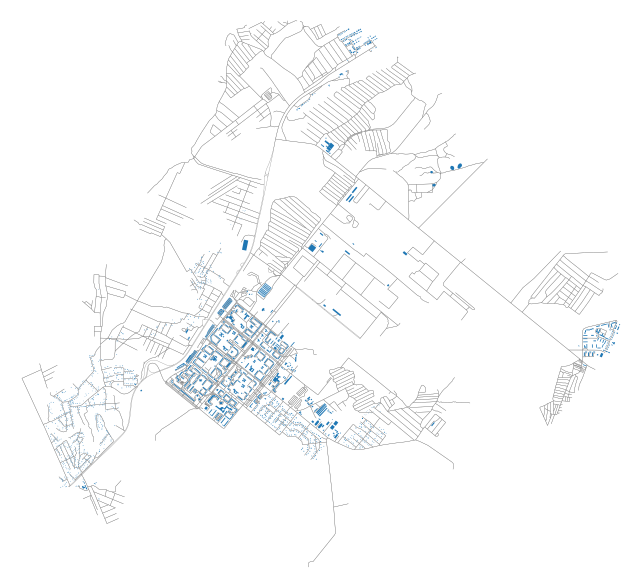

In [3]:
from fire_units.settings import DEFAULT_SPEEDS
from graphs.speeds import kmh_to_mm, set_graph_travel_times

# Загружаем данные
G = ox.load_graphml(r'tests\data\test_rng.ml')
print(G.number_of_nodes(), G.number_of_edges())
buildings = gpd.read_file(r'tests\data\buildings.gpkg')

# Устанавливаем скорости движения
set_graph_travel_times(G, speeds=DEFAULT_SPEEDS, morph_function=kmh_to_mm)


# Сопоставляем здания с узлами
# Узлы графа:
nodes_gdf = ox.graph_to_gdfs(G, edges=False)
nodes_gdf = ox.projection.project_gdf(nodes_gdf)
print('Узлов исходного ГДС:', len(nodes_gdf))

# Здания
print('Зданий:', len(buildings))
buildings = ox.projection.project_gdf(buildings, to_crs=nodes_gdf.crs)
buildings_centr = buildings.geometry.centroid
nearest_nodes = ox.nearest_nodes(ox.projection.project_graph(G), buildings_centr.x, buildings_centr.y, return_dist=True)
buildings['node'] = nearest_nodes[0]
buildings['node_distance'] = nearest_nodes[1]
buildings = buildings.query('node_distance <= 100')
buildings = ox.projection.project_gdf(buildings, to_latlong=True)
print('Зданий:', len(buildings))

fig, ax = ox.plot_graph(G, node_size=0, show=False, close=False, bgcolor='white', edge_color='grey', edge_linewidth=0.2)
buildings.plot(ax=ax)

In [4]:
# Создаем реверсный граф
GR = nx.reverse(G, copy=True)

# 1. Разработка алгоритма

## 1.1. Обратный Дейкстра

! Не имеет смысла. т.к. достаточно один раз развернуть граф.

In [5]:
# from typing import Any
# from networkx import Graph


# def multi_source_dijkstra_reversed(
#         G: Graph,
#         sources: Any,
#         target: Any | None = None,
#         cutoff: Any | None = None,
#         weight: str = "weight"
# ):
#     G = nx.reverse(G, copy=True)
#     return nx.multi_source_dijkstra(
#         G,
#         sources = sources,
#         target  = target,
#         cutoff  = cutoff,
#         weight  = weight, 
#         )

## 1.2. Расчет матрицы достижимости от всех зданий

In [6]:
buildings.head(5)

,osmid,name,amenity,building,addr:street,addr:housenumber,building:levels,building:flats,geometry,node,node_distance
0,114435873,None,None,apartments,улица Ленинского Комсомола,2,9,None,"POLYGON ((93.34238 56.12589, 93.3425 56.12597,...",9085465307,6.523538
1,114435874,None,None,store,улица Ленинского Комсомола,None,None,None,"POLYGON ((93.33886 56.12348, 93.33875 56.1234,...",9085465281,15.532267
2,114435883,None,None,apartments,улица Ленинского Комсомола,14,9,None,"POLYGON ((93.33509 56.12247, 93.33522 56.12256...",1548378909,15.114030
3,114435884,Айсберг,None,retail,улица Ленинского Комсомола,16,2,None,"POLYGON ((93.33517 56.12089, 93.33507 56.12093...",1548378914,29.840848
4,114435890,None,None,store,улица Ленинского Комсомола,10,2,None,"POLYGON ((93.33343 56.12335, 93.33358 56.12328...",1526082578,25.869531


In [7]:
from genesis.swiss_knife import MSF
from genesis.utils import Progressbar

time_bound = 3


df_size = len(buildings)
pb = Progressbar(df_size, bins=40)

d = {}
for id, building in buildings.iterrows():
    node = building['node']
    # length, path = multi_source_dijkstra_reversed(G, sources = [node], cutoff = time_bound, weight = 'travel_time')
    length, path = MSF(GR, sources = [node], cutoff = time_bound, weight = 'travel_time')
    # length = {k:v for k,v in length.items() if v in }
    d[id] = pd.Series(length).notna()
    pb()

matrix = pd.DataFrame(d).T
matrix.shape

|########################################| 100.0%


(1502, 4442)

In [8]:
matrix

,290700344,290700348,290700352,290700353,290700355,290700356,290700357,290700359,290700360,290700361,...,10861562812,10861562813,10861562814,10861562815,10861562816,10861562817,10861562818,10861562819,10861562820,10861562821
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1590,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1591,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1592,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1593,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [9]:
matrix.to_csv('greedy_adding_matrix.csv')

## 1.3. Алгоритм

1. Если матрица не равна нулю (имеется хоть одна строка или неприкрытое здание) увеличиваем количество мест размещения на 1.
Ищем максимальную сумму среди всех узлов - это тот у зел, размещение в котором обеспечит покрытие максимального количества зданий
2. Определяем его номер
3. Поэтому номеру получаем маску покрытых узлов
4. Из матрицы достижимости выбрасываем все узлы покрытые имеющимся размещением

5. Повторяем все предыдущие шаги до тех пор пока не закончится вся матрица

In [10]:
pd.set_option('future.no_silent_downcasting', True)

In [11]:
matrix_temp = matrix.copy()
units = []
covered_buildings_count = 0

print(len(matrix_temp))
while len(matrix_temp) > 0:
    node_id = matrix_temp.columns[np.argmax(np.sum(matrix_temp, axis=0))]
    units.append(int(node_id))
    node_column = matrix_temp[node_id]

    covered_buildings_count += node_column.sum()
    print('Прикрыто зданий', node_column.sum(), 'и всего:', covered_buildings_count)
    # node_column = node_column.fillna(False)

    # # Определения количества прикрытых зданий
    # nodes_list = list(node_column[node_column].index)
    # covered_buildings_count += len(buildings.query(f'node in @nodes_list'))
    # print(len(buildings.query(f'node in @nodes_list')), covered_buildings_count)

    matrix_temp = matrix_temp[node_column.isna()]
    print(matrix_temp.shape, len(units), 100 * (1 - (len(matrix_temp) / len(matrix))), ' '*5)   #, end = '\r')
    # print(matrix_temp.shape, len(units), 100 * (covered_buildings_count / len(buildings)), ' '*5)    

1502
Прикрыто зданий 427 и всего: 427
(1075, 4442) 1 28.42876165113183      
Прикрыто зданий 315 и всего: 742
(760, 4442) 2 49.40079893475367      
Прикрыто зданий 170 и всего: 912
(590, 4442) 3 60.719041278295606      
Прикрыто зданий 128 и всего: 1040
(462, 4442) 4 69.2410119840213      
Прикрыто зданий 91 и всего: 1131
(371, 4442) 5 75.29960053262317      
Прикрыто зданий 74 и всего: 1205
(297, 4442) 6 80.22636484687085      
Прикрыто зданий 66 и всего: 1271
(231, 4442) 7 84.62050599201065      
Прикрыто зданий 63 и всего: 1334
(168, 4442) 8 88.81491344873503      
Прикрыто зданий 49 и всего: 1383
(119, 4442) 9 92.07723035952064      
Прикрыто зданий 27 и всего: 1410
(92, 4442) 10 93.87483355525966      
Прикрыто зданий 17 и всего: 1427
(75, 4442) 11 95.00665778961384      
Прикрыто зданий 14 и всего: 1441
(61, 4442) 12 95.93874833555259      
Прикрыто зданий 14 и всего: 1455
(47, 4442) 13 96.87083888149135      
Прикрыто зданий 11 и всего: 1466
(36, 4442) 14 97.60319573901465      

In [12]:
units

[1998227427,
 1533814277,
 1676510285,
 5940099708,
 3981463630,
 290700344,
 1533814276,
 868999655,
 1998227475,
 2034402073,
 3119947220,
 426923793,
 2054468488,
 2034401275,
 2034401716,
 868823409,
 5574211404,
 426923828,
 2034402108,
 10816267598,
 1297036351,
 360828220,
 1297042718,
 3287063257,
 4116025736,
 4116034584,
 4116035737,
 10816267926]

<Axes: >

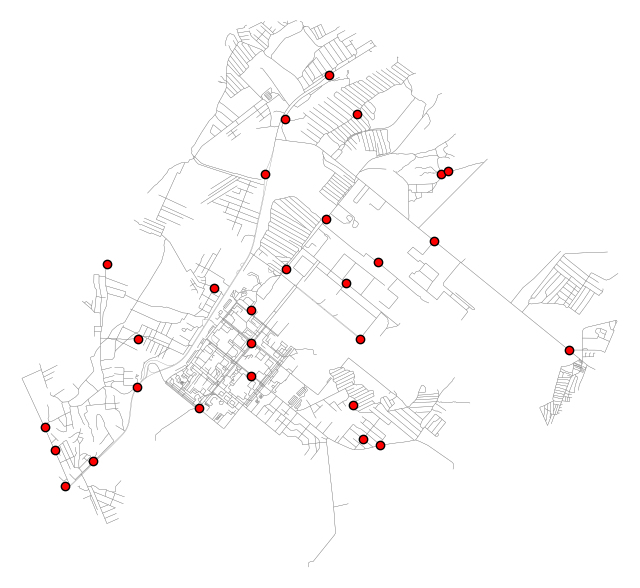

In [13]:
nodes_gdf = ox.graph_to_gdfs(G, edges=False)

fig,ax = ox.plot_graph(G, node_size=0, show=False, close=False, bgcolor='white', edge_color='grey', edge_linewidth=0.2)
nodes_gdf.loc[units].plot(ax=ax, color='red', edgecolor='black')


# 2. Сопоставление со временем расчета для инструментов **genesis**

Проверка для полученных жадным добавлением размещений

In [14]:
units[:5]

[1998227427, 1533814277, 1676510285, 5940099708, 3981463630]

In [25]:
from genesis.metrics import CoverIndex, ArrivalTime
from genesis.states import FirstArrivalUnitState
from fire_units.metrics import CoverIndexBuilding


dynamic_nodes = {}
i = 0
for n in units[:9]:
    dynamic_nodes[n] = f'pre {i}'
    i+=1

# dynamic_nodes = {
#     1998227427: 'pre1',
#     1533814277: 'pre2',
#     1676510285: 'pre3',
#     5940099708: 'pre4',
#     3981463630: 'pre5',
# }

times, _ = FirstArrivalUnitState(delay=0)(env = G, points = dynamic_nodes)
print('Новых ПСЧ:', len(dynamic_nodes), 'Всего ПСЧ:', len(units))
print('ИП-3 = ', CoverIndexBuilding(buildings, ip_val = 3)(times), '%, tпр = ', ArrivalTime()(times))

# print_metrics(G, dynamic_nodes, {})

Новых ПСЧ: 9 Всего ПСЧ: 28
ИП-3 =  92.38476953907815 %, tпр =  4.007661584824722


In [16]:
len(times[times <= 3]), len(times)

(1916, 5504)

In [17]:
from genesis.metrics import CoverIndex, ArrivalTime
from genesis.states import FirstArrivalUnitState


def iter_func(**kwds):
    'Функция вывода хода расчета'
    i = kwds['i']
    best_metric = kwds['best_metric']
    print(f'Копт: шаг {i} лучшая метирка: {best_metric}')

# mclp_history = []
def mclp_end_function(iteration, best_metric, dynamic_nodes, static_nodes, **kwargs):
    units_count = len(dynamic_nodes) + len(static_nodes)
    msg = f'Итерация: {iteration} | Подразделений {units_count} | Лучшая метрика: {best_metric}'
    print(msg)


def epoch_end_function(epoch, best_metric, cur_metric, **kwargs):
    print(f'Эпоха: {epoch} |', f'Лучшая метрика: {best_metric} |', f'Текущая метрика: {cur_metric} |')

def stop_case_function(target_ip=90,
                            ip_val=10):
    def stop_case_function_(value,
                            iteration,
                            best_metric,
                            current_metric,
                            dynamic_nodes,
                            static_nodes,
                            ):

        ip = value
        print(f'Текущий ИП-{ip_val}:', ip, target_ip)
        if ip >= target_ip:
            return True
        return False
    
    return stop_case_function_

def print_metrics(env, dynamic_nodes, existed_units_dict, ip_val=3):
    all_nodes = {**existed_units_dict, **dynamic_nodes}
    times, _ = FirstArrivalUnitState(delay=0)(env = env, points = all_nodes)
    print('Новых ПСЧ:', len(dynamic_nodes), 'Всего ПСЧ:', len(all_nodes))
    print(f'ИП-{ip_val} = ', CoverIndex(ip_val)(times), '%, tпр = ', ArrivalTime()(times))

In [19]:

from fire_units.best_points import BestNodeHillClimbing_HD_Max_Mean
from fire_units.mclp import BestNodesGAKopt
from fire_units.metrics import CoverIndexBuilding
from genesis.lscp import LSCPCommon, drop_trash_points
from genesis.mclp import BestNodesKoptG
from genesis.metrics import ArrivalTime
from genesis.point_selectors import GenesisNodeSelector, RandomNodesSelector
from genesis.states import FirstArrivalUnitState
from genesis.stop_cases import NSameStopCase


target_ip = 90


# metric_opt = ArrivalTime()
metric_target = CoverIndexBuilding(buildings, ip_val = 3)

# Функция оптимизации k узлов методом hillclimber
bnhc = BestNodeHillClimbing_HD_Max_Mean(state_function=FirstArrivalUnitState(delay=0))

kopt = BestNodesKoptG(state_function=FirstArrivalUnitState(delay=0),
                       metric_function = metric_target,
                       best_point_function=bnhc,
                       iterations=3,
                       iter_calc_end_function=iter_func,
                       )


mclp = BestNodesGAKopt(state_function = FirstArrivalUnitState(delay=0),
                    # metric_function = ArrivalTime(),            # Оптимизируем среднее время прибытия в любой узел
                    metric_function = metric_target,                        # Оптимизируем ИПЗ-10
                    kopt_function = kopt,
                    node_selector = RandomNodesSelector(),
                    # node_selector = GenesisNodeSelector(FirstArrivalUnitState(delay=0), metric_target),                    
                    population_size = 75,
                    epochs = 25,
                    elite_size = 20,
                    epoch_end_function = epoch_end_function,
                    mutation_max_count = 5,
                    stop_case_function = NSameStopCase(15)      # Условие остановки не менее N одинаковых метрик
                    )


genesis = LSCPCommon(
                    mclp_function = mclp,
                    # mclp_function = kopt,
                    point_selector = RandomNodesSelector(),
                    # point_selector = GenesisNodeSelector(FirstArrivalUnitState(delay=0), metric_target),
                    metric_function = metric_target,                        
                    # stop_case_function = MoreEqualStopCase(90),     # stop_case_function,
                    stop_case_function = stop_case_function(target_ip = target_ip, ip_val=3),     # stop_case_function,
                    start_names_index = 10,
                    names_pattern='псч {}',
                    after_mclp_function = mclp_end_function,
                    )

dynamic_nodes = {
    list(nodes_gdf.index)[100]: 'псч А',
    list(nodes_gdf.index)[200]: 'псч Б',
    # list(nodes_gdf.index)[300]: 'псч В',
}

# Собственно расчет
print('До LSCP:', len(dynamic_nodes))
best_dynamic_nodes, best_metric = genesis(env = G,
                                dynamic_nodes = dynamic_nodes,
                                # static_nodes = existed_units_dict,                          
                                # area = points_mask,
                                )
print('После LSCP:', len(best_dynamic_nodes))

optimal_nodes, best_metric = drop_trash_points(G,
                                FirstArrivalUnitState(delay=0),
                                metric_target,
                                stop_case_function(target_ip = target_ip),
                                best_dynamic_nodes,
                                # static_nodes = existed_units_dict,   
                                )
print('После отброса:', len(optimal_nodes))
# mclp_end_function('add', best_metric, optimal_nodes)

До LSCP: 2
Эпоха: 0 | Лучшая метрика: 44.555778223112895 | Текущая метрика: 44.555778223112895 |
Эпоха: 1 | Лучшая метрика: 44.555778223112895 | Текущая метрика: 44.555778223112895 |
Эпоха: 2 | Лучшая метрика: 44.555778223112895 | Текущая метрика: 44.555778223112895 |
Эпоха: 3 | Лучшая метрика: 44.555778223112895 | Текущая метрика: 44.555778223112895 |
Эпоха: 4 | Лучшая метрика: 44.555778223112895 | Текущая метрика: 44.555778223112895 |
Эпоха: 5 | Лучшая метрика: 48.162992651970605 | Текущая метрика: 48.162992651970605 |
Эпоха: 6 | Лучшая метрика: 48.162992651970605 | Текущая метрика: 48.162992651970605 |
Эпоха: 7 | Лучшая метрика: 48.162992651970605 | Текущая метрика: 48.162992651970605 |
Эпоха: 8 | Лучшая метрика: 48.162992651970605 | Текущая метрика: 48.162992651970605 |
Эпоха: 9 | Лучшая метрика: 48.162992651970605 | Текущая метрика: 48.162992651970605 |
Эпоха: 10 | Лучшая метрика: 48.162992651970605 | Текущая метрика: 48.162992651970605 |
Эпоха: 11 | Лучшая метрика: 48.16299265197

Оптимизация размещения N подразделений аналогичных предложенным при помощи жадного добавления

In [ ]:
# import random

# # Создание словаря предварительно размещенных подразделений
# dynamic_nodes = {}
# i = 1
# # for n in random.choices(list(nodes_gdf.index), k=9):
# for n in units[:9]:
#     dynamic_nodes[n] = f'pre {i}'
#     i += 1

# dynamic_nodes

{1998227427: 'pre 1',
 1533814277: 'pre 2',
 1676510285: 'pre 3',
 5940099708: 'pre 4',
 3981463630: 'pre 5',
 290700344: 'pre 6',
 1533814276: 'pre 7',
 868999655: 'pre 8',
 1998227475: 'pre 9'}

In [22]:
from genesis.best_points import BestNodeBee


metric_target = CoverIndexBuilding(buildings, ip_val = 3)

# Функция оптимизации k узлов методом hillclimber
bnhc = BestNodeHillClimbing_HD_Max_Mean(state_function=FirstArrivalUnitState(delay=0))
abc = BestNodeBee(state_function=FirstArrivalUnitState(delay=0),
                  metric_function=ArrivalTime(),
                  scouts_count=20,
                  best_scouts_count=4)


kopt = BestNodesKoptG(state_function=FirstArrivalUnitState(delay=0),
                       metric_function = metric_target,
                       best_point_function=abc,
                       iterations=3,
                       iter_calc_end_function=iter_func,
                       )


mclp = BestNodesGAKopt(state_function = FirstArrivalUnitState(delay=0),
                    # metric_function = ArrivalTime(),            # Оптимизируем среднее время прибытия в любой узел
                    metric_function = metric_target,                        # Оптимизируем ИПЗ-10
                    kopt_function = kopt,
                    node_selector = RandomNodesSelector(),
                    # node_selector = GenesisNodeSelector(FirstArrivalUnitState(delay=0), metric_target),                    
                    population_size = 200,
                    epochs = 25,
                    elite_size = 25,
                    epoch_end_function = epoch_end_function,
                    mutation_max_count = 10,
                    stop_case_function = NSameStopCase(15)      # Условие остановки не менее N одинаковых метрик
                    )



# best_dynamic_nodes, best_metric = mclp(env = G,
#                                 dynamic_nodes = optimal_nodes,
#                                 )

In [23]:
best_dynamic_nodes, best_metric = kopt(env = G,
                                dynamic_nodes = optimal_nodes,
                                )

Копт: шаг 0 лучшая метирка: 90.91516366065464
Копт: шаг 1 лучшая метирка: 90.91516366065464
Копт: шаг 2 лучшая метирка: 90.91516366065464


In [24]:
best_metric

90.91516366065464